In [10]:
# 1. Imports y rutas

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuración de rutas
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter5"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter5"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DATA_DIR:", PROCESSED_DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)

PROJECT_ROOT: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio
PROCESSED_DATA_DIR: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed
FIGURES_DIR: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter5
TABLES_DIR: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5


In [11]:
# 2. Carga del dataset con regímenes

regime_path = PROCESSED_DATA_DIR / "dataset_cap4_regimes_train.csv"

df = pd.read_csv(regime_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Rango de fechas:", df["date"].min(), "->", df["date"].max())
print("Columnas:")
print(list(df.columns))

required_cols = ["date", "ret_1d", "regime"]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas necesarias: {missing_cols}")

Shape: (5274, 7)
Rango de fechas: 2000-03-28 00:00:00 -> 2020-12-31 00:00:00
Columnas:
['date', 'sample_split_main', 'ret_1d', 'ewma_vol', 'cvar_95_60d', 'regime', 'regime_block']


In [12]:
# 3. Definición de exposición por régimen

# Según la interpretación obtenida:
# Regime 0 = bajo riesgo
# Regime 2 = riesgo intermedio
# Regime 1 = estrés

regime_exposure_map = {
    0: 1.0,   # exposición completa
    2: 0.5,   # exposición parcial
    1: 0.0,   # sin exposición en estrés
}

df["target_exposure"] = df["regime"].map(regime_exposure_map)

print("Exposición media:")
print(df["target_exposure"].describe())

print("Observaciones por exposición:")
print(df["target_exposure"].value_counts().sort_index())

Exposición media:
count    5274.000000
mean        0.632916
std         0.331604
min         0.000000
25%         0.500000
50%         0.500000
75%         1.000000
max         1.000000
Name: target_exposure, dtype: float64
Observaciones por exposición:
target_exposure
0.0     645
0.5    2582
1.0    2047
Name: count, dtype: int64


In [13]:
# 4. Prevención de look-ahead bias

# La exposición decidida con la información del día t se aplica al retorno del día t+1.
# Por tanto, desplazamos la señal un día.

df["strategy_exposure"] = df["target_exposure"].shift(1)

# Primera observación sin señal previa: se elimina
df_backtest = df.dropna(subset=["strategy_exposure"]).copy()

print("Shape backtest:", df_backtest.shape)
print("Rango backtest:", df_backtest["date"].min(), "->", df_backtest["date"].max())

display(df_backtest[["date", "ret_1d", "regime", "target_exposure", "strategy_exposure"]].head())

Shape backtest: (5273, 9)
Rango backtest: 2000-03-29 00:00:00 -> 2020-12-31 00:00:00


,date,ret_1d,regime,target_exposure,strategy_exposure
1,2000-03-29,-0.010083,0,1.0,1.0
2,2000-03-30,-0.021337,2,0.5,1.0
3,2000-03-31,0.008549,2,0.5,0.5
4,2000-04-03,-0.021049,2,0.5,0.5
5,2000-04-04,-0.008784,2,0.5,0.5


In [14]:
# 5. Construcción de retornos de estrategia y benchmark

df_backtest["benchmark_return"] = df_backtest["ret_1d"]

df_backtest["strategy_return"] = (
    df_backtest["strategy_exposure"] * df_backtest["ret_1d"]
)

df_backtest["benchmark_cum"] = np.exp(df_backtest["benchmark_return"].cumsum())
df_backtest["strategy_cum"] = np.exp(df_backtest["strategy_return"].cumsum())

display(df_backtest[[
    "date",
    "ret_1d",
    "regime",
    "strategy_exposure",
    "benchmark_return",
    "strategy_return",
    "benchmark_cum",
    "strategy_cum"
]].head())

,date,ret_1d,regime,strategy_exposure,benchmark_return,strategy_return,benchmark_cum,strategy_cum
1,2000-03-29,-0.010083,0,1.0,-0.010083,-0.010083,0.989968,0.989968
2,2000-03-30,-0.021337,2,1.0,-0.021337,-0.021337,0.969069,0.969069
3,2000-03-31,0.008549,2,0.5,0.008549,0.004275,0.977390,0.973220
4,2000-04-03,-0.021049,2,0.5,-0.021049,-0.010525,0.957031,0.963031
5,2000-04-04,-0.008784,2,0.5,-0.008784,-0.004392,0.948662,0.958811


In [15]:
# 6. Métricas de performance y riesgo

def compute_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_max - 1
    return drawdown

def historical_var(returns, alpha=0.95):
    return returns.quantile(1 - alpha)

def historical_cvar(returns, alpha=0.95):
    var = historical_var(returns, alpha)
    return returns[returns <= var].mean()

benchmark_drawdown = compute_drawdown(df_backtest["benchmark_cum"])
strategy_drawdown = compute_drawdown(df_backtest["strategy_cum"])

metrics = pd.DataFrame(
    {
        "strategy": ["Buy & Hold", "Regime-based"],
        "total_return": [
            df_backtest["benchmark_cum"].iloc[-1] - 1,
            df_backtest["strategy_cum"].iloc[-1] - 1,
        ],
        "mean_daily_return": [
            df_backtest["benchmark_return"].mean(),
            df_backtest["strategy_return"].mean(),
        ],
        "daily_volatility": [
            df_backtest["benchmark_return"].std(),
            df_backtest["strategy_return"].std(),
        ],
        "VaR_95": [
            historical_var(df_backtest["benchmark_return"]),
            historical_var(df_backtest["strategy_return"]),
        ],
        "CVaR_95": [
            historical_cvar(df_backtest["benchmark_return"]),
            historical_cvar(df_backtest["strategy_return"]),
        ],
        "max_drawdown": [
            benchmark_drawdown.min(),
            strategy_drawdown.min(),
        ],
    }
)

display(metrics)

,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,-0.338822,-0.000078,0.014807,-0.023753,-0.035212,-0.626464
1,Regime-based,-0.356085,-0.000083,0.007476,-0.012963,-0.018349,-0.551111


In [16]:
# Cargar dataset completo con regímenes (asegúrate de tener 'regime' con filtered probs)
path = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full.csv"  # si no existe, exporta uno “full” en nb03
df_full = pd.read_csv(path, parse_dates=["date"]).sort_values("date")

# Split
df_test = df_full[df_full["sample_split_main"] == "test"].copy()
df_test = df_test.sort_values("date").reset_index(drop=True)

print(df_test["date"].min(), "->", df_test["date"].max())

2021-01-04 00:00:00 -> 2026-04-23 00:00:00


In [20]:
print("df_full shape:", df_full.shape)
print(df_full["sample_split_main"].value_counts())

print("df_test shape:", df_test.shape)
print("df_test_bt shape:", df_test_bt.shape)

df_full shape: (5274, 9)
sample_split_main
train    5274
Name: count, dtype: int64
df_test shape: (0, 9)
df_test_bt shape: (0, 13)


In [22]:
# 7. Construcción del test set (out-of-sample)

# Cargar SIEMPRE el dataset completo con train + test
path = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full.csv"

df_full = (
    pd.read_csv(path, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("df_full shape:", df_full.shape)
print(df_full["sample_split_main"].value_counts(dropna=False))

df_test = df_full[df_full["sample_split_main"] == "test"].copy()
df_test = df_test.sort_values("date").reset_index(drop=True)

print("Shape test:", df_test.shape)
print("Rango test:", df_test["date"].min(), "->", df_test["date"].max())

# Exposición por régimen
regime_exposure_map = {
    0: 1.0,
    2: 0.75,
    1: 0.25,
}

df_test["target_exposure"] = df_test["regime"].map(regime_exposure_map)

# Evitar look-ahead bias
df_test["strategy_exposure"] = df_test["target_exposure"].shift(1)
df_test_bt = df_test.dropna(subset=["strategy_exposure"]).copy()

print("df_test_bt shape:", df_test_bt.shape)

# Retornos
df_test_bt["benchmark_return"] = df_test_bt["ret_1d"]

df_test_bt["strategy_return"] = (
    df_test_bt["strategy_exposure"] * df_test_bt["ret_1d"]
)

df_test_bt["benchmark_cum"] = np.exp(df_test_bt["benchmark_return"].cumsum())
df_test_bt["strategy_cum"] = np.exp(df_test_bt["strategy_return"].cumsum())

display(df_test_bt.head())

df_full shape: (6631, 6)
sample_split_main
train    5274
test     1357
Name: count, dtype: int64
Shape test: (1357, 6)
Rango test: 2021-01-04 00:00:00 -> 2026-04-23 00:00:00
df_test_bt shape: (1356, 8)


,date,sample_split_main,ret_1d,ewma_vol,cvar_95_60d,regime,target_exposure,strategy_exposure,benchmark_return,strategy_return,benchmark_cum,strategy_cum
1,2021-01-05,test,-0.000951,0.012880,-0.026634,0,1.00,0.75,-0.000951,-0.000713,0.999049,0.999287
2,2021-01-06,test,0.031483,0.014677,-0.026634,2,0.75,1.00,0.031483,0.031483,1.031003,1.031248
3,2021-01-07,test,0.004242,0.014268,-0.026634,2,0.75,0.75,0.004242,0.003182,1.035386,1.034535
4,2021-01-08,test,0.002608,0.013848,-0.026634,2,0.75,0.75,0.002608,0.001956,1.038090,1.036560
5,2021-01-11,test,-0.005989,0.013506,-0.026634,2,0.75,0.75,-0.005989,-0.004491,1.031892,1.031915


In [23]:
# 11. Métricas OUT-OF-SAMPLE

benchmark_drawdown_test = compute_drawdown(df_test_bt["benchmark_cum"])
strategy_drawdown_test = compute_drawdown(df_test_bt["strategy_cum"])

metrics_test = pd.DataFrame(
    {
        "strategy": ["Buy & Hold", "Regime-based"],
        "total_return": [
            df_test_bt["benchmark_cum"].iloc[-1] - 1,
            df_test_bt["strategy_cum"].iloc[-1] - 1,
        ],
        "mean_daily_return": [
            df_test_bt["benchmark_return"].mean(),
            df_test_bt["strategy_return"].mean(),
        ],
        "daily_volatility": [
            df_test_bt["benchmark_return"].std(),
            df_test_bt["strategy_return"].std(),
        ],
        "VaR_95": [
            historical_var(df_test_bt["benchmark_return"]),
            historical_var(df_test_bt["strategy_return"]),
        ],
        "CVaR_95": [
            historical_cvar(df_test_bt["benchmark_return"]),
            historical_cvar(df_test_bt["strategy_return"]),
        ],
        "max_drawdown": [
            benchmark_drawdown_test.min(),
            strategy_drawdown_test.min(),
        ],
    }
)

display(metrics_test)

,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.208354,0.000584,0.010256,-0.015875,-0.023772,-0.217647
1,Regime-based,0.895205,0.000471,0.008695,-0.014089,-0.020212,-0.232797


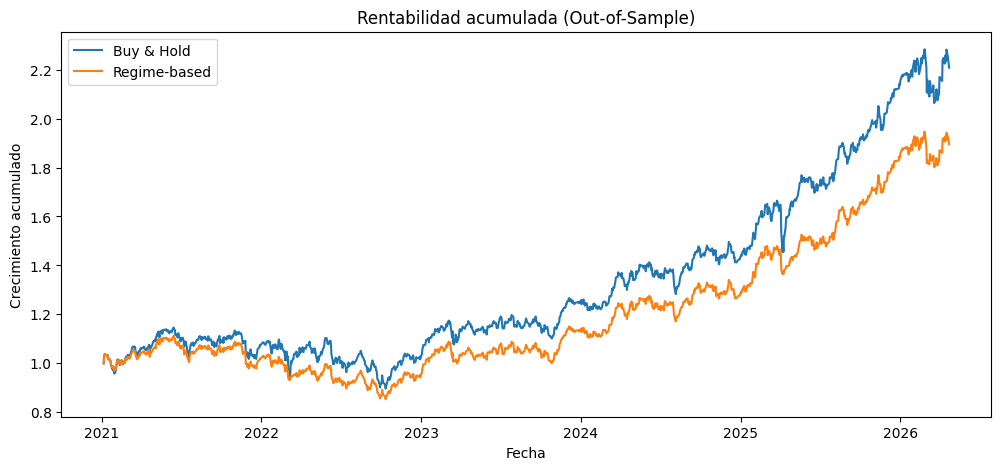

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df_test_bt["date"], df_test_bt["benchmark_cum"], label="Buy & Hold")
plt.plot(df_test_bt["date"], df_test_bt["strategy_cum"], label="Regime-based")

plt.title("Rentabilidad acumulada (Out-of-Sample)")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento acumulado")
plt.legend()

plt.show()

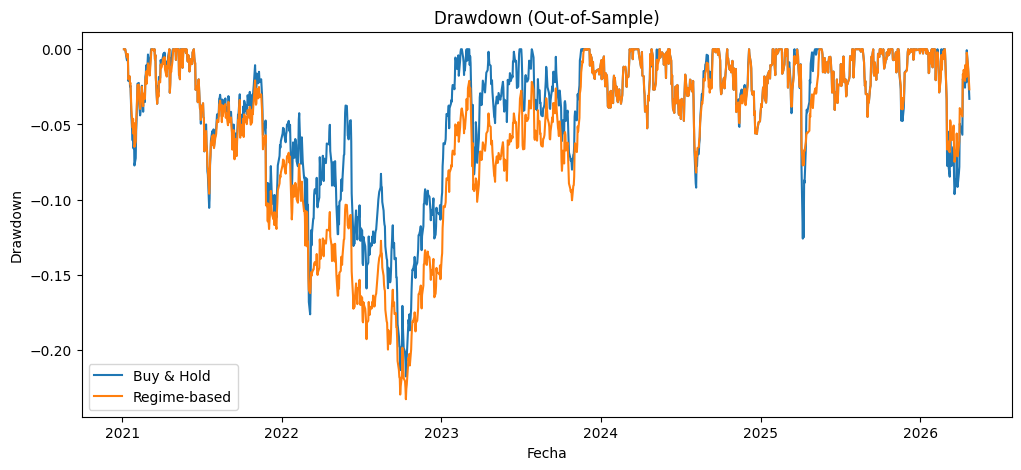

In [25]:
plt.figure(figsize=(12,5))

plt.plot(df_test_bt["date"], benchmark_drawdown_test, label="Buy & Hold")
plt.plot(df_test_bt["date"], strategy_drawdown_test, label="Regime-based")

plt.title("Drawdown (Out-of-Sample)")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()

plt.show()

In [26]:
metrics_test.to_csv(TABLES_DIR / "oos_performance_metrics.csv", index=False)

df_test_bt.to_csv(PROCESSED_DATA_DIR / "backtest_oos_results.csv", index=False)